# 01 – Preprocessing
Load the raw chocolate ratings dataset, clean column names and dtypes, and save the result to `data/processed/`.

## Load data

In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv('../data/raw/chocolate.csv')
df.head()

,Company,Specific Bean\nOrigin,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
0,A. Morin,Agua Grande,2016,63%,France,3.75,Blend,Sao Tome
1,A. Morin,Kpime,2015,70%,France,2.75,Blend,Togo
2,A. Morin,Atsane,2015,70%,France,3.00,Blend,Togo
3,A. Morin,Akata,2015,70%,France,3.50,Blend,Togo
4,A. Morin,Quilla,2015,70%,France,3.50,Blend,Peru


## Inspect shape and columns

In [7]:
s = df.shape
cols = df.columns
print(s)
print(cols)

(1795, 8)
Index(['Company', 'Specific Bean\nOrigin', 'Review\nDate', 'Cocoa\nPercent',
       'Company\nLocation', 'Rating', 'Bean\nType', 'Broad Bean\nOrigin'],
      dtype='str')


## Clean column names
Some headers contain embedded newline characters (`\n`); replace them with spaces.

In [9]:
df.columns = ['Company', 'Specific Bean Origin', 'Review Date', 'Cocoa Percent', 'Company Location', 'Rating', 'Bean Type', 'Broad Bean Origin']

Check dtypes with `info()`.

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1795 non-null   str    
 1   Specific Bean Origin  1795 non-null   str    
 2   Review Date           1795 non-null   int64  
 3   Cocoa Percent         1795 non-null   str    
 4   Company Location      1795 non-null   str    
 5   Rating                1795 non-null   float64
 6   Bean Type             1795 non-null   str    
 7   Broad Bean Origin     1794 non-null   str    
dtypes: float64(1), int64(1), str(6)
memory usage: 112.3 KB


## Cast text columns to `string`
Convert `object` columns holding text to the pandas `string` dtype.

In [13]:
df[['Company','Specific Bean Origin','Cocoa Percent','Company Location','Bean Type','Broad Bean Origin']] = df[['Company','Specific Bean Origin','Cocoa Percent','Company Location','Bean Type','Broad Bean Origin']].astype('string')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1795 non-null   string 
 1   Specific Bean Origin  1795 non-null   string 
 2   Review Date           1795 non-null   int64  
 3   Cocoa Percent         1795 non-null   string 
 4   Company Location      1795 non-null   string 
 5   Rating                1795 non-null   float64
 6   Bean Type             1795 non-null   string 
 7   Broad Bean Origin     1794 non-null   string 
dtypes: float64(1), int64(1), string(6)
memory usage: 112.3 KB


## Convert `Cocoa Percent` to numeric
Strip the `%` sign and cast to `float`.

In [15]:
df['Cocoa Percent'] = df['Cocoa Percent'].str.replace('%','').astype(float)
df.head()

,Company,Specific Bean Origin,Review Date,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
0,A. Morin,Agua Grande,2016,63.0,France,3.75,Blend,Sao Tome
1,A. Morin,Kpime,2015,70.0,France,2.75,Blend,Togo
2,A. Morin,Atsane,2015,70.0,France,3.00,Blend,Togo
3,A. Morin,Akata,2015,70.0,France,3.50,Blend,Togo
4,A. Morin,Quilla,2015,70.0,France,3.50,Blend,Peru


## Cocoa percent distribution
Most bars are at 70% cocoa.

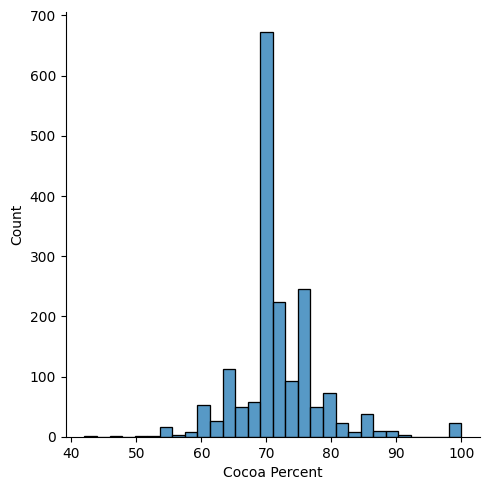

In [16]:
import seaborn as sns
sns.displot(df, x = 'Cocoa Percent', bins = 30)

## Save

In [23]:
df.to_csv('../data/processed/chocolate_preprocessed.csv', index=False)